In [2]:
%pip install numpy matplotlib scipy librosa soundfile

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: D:\python\python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import librosa
import soundfile as sf

print("Semua library berhasil di-load!")
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Librosa:", librosa.__version__)

Semua library berhasil di-load!
NumPy: 2.5.3
SciPy: 1.18.1
Librosa: 1.0.0


In [1]:
# Membaca file audio
audio, sr = librosa.load("Recording.wav", sr=None)

print("Audio berhasil dibaca!")
print("Jumlah sample:", len(audio))
print("Sampling rate:", sr, "Hz")
print("Durasi:", len(audio) / sr, "detik")

NameError: name 'librosa' is not defined

In [2]:
import librosa

In [3]:
audio, sr = librosa.load("Recording.wav", sr=None)

print("Audio berhasil dibaca!")
print("Jumlah sample:", len(audio))
print("Sampling rate:", sr, "Hz")
print("Durasi:", len(audio) / sr, "detik")

Audio berhasil dibaca!
Jumlah sample: 324607
Sampling rate: 48000 Hz
Durasi: 6.762645833333333 detik


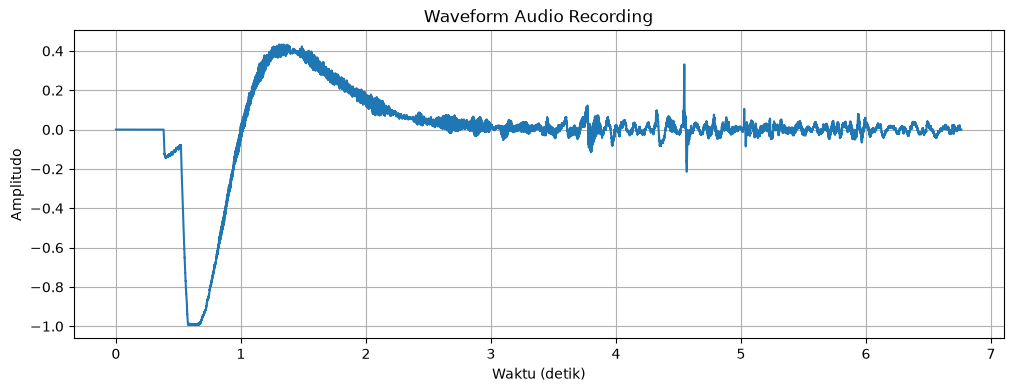

In [4]:
import matplotlib.pyplot as plt
import numpy as np

waktu = np.arange(len(audio)) / sr

plt.figure(figsize=(12, 4))
plt.plot(waktu, audio)
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.title("Waveform Audio Recording")
plt.grid()
plt.show()

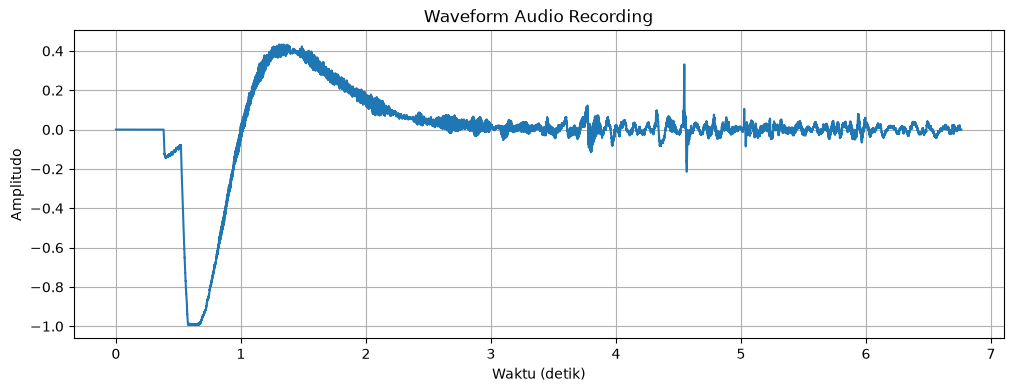

In [5]:
import matplotlib.pyplot as plt
import numpy as np

waktu = np.arange(len(audio)) / sr

plt.figure(figsize=(12, 4))
plt.plot(waktu, audio)
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.title("Waveform Audio Recording")
plt.grid()

plt.savefig("waveform_recording.png", dpi=300, bbox_inches="tight")

plt.show()

In [8]:
audio, sr = librosa.load("audio_original.wav", sr=None)

print("Sampling rate (fs):", sr, "Hz")
print("Durasi:", len(audio) / sr, "detik")
print("Jumlah sampel:", len(audio))
print("Tipe data:", audio.dtype)

Sampling rate (fs): 48000 Hz
Durasi: 11.498666666666667 detik
Jumlah sampel: 551936
Tipe data: float32


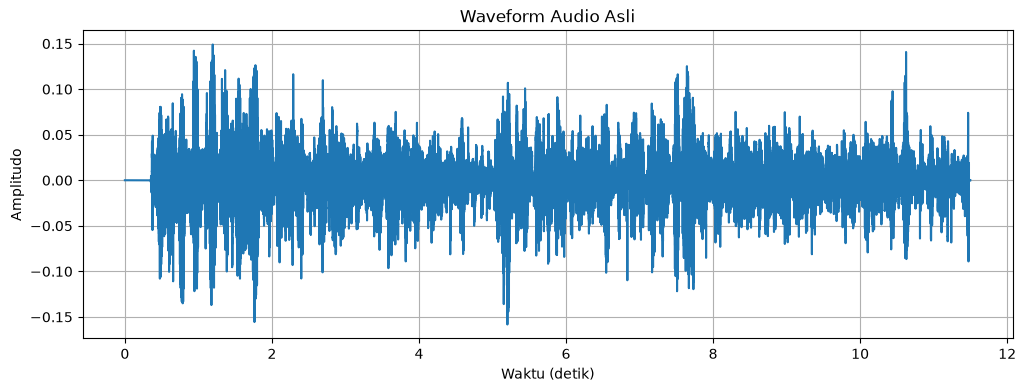

In [10]:
waktu = np.arange(len(audio)) / sr

plt.figure(figsize=(12, 4))
plt.plot(waktu, audio)

plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")

plt.title("Waveform Audio Asli")

plt.grid()

plt.savefig("waveform_recording.png", dpi=300, bbox_inches="tight")

plt.show()

Dari grafik waveform, terlihat bahwa amplitudo sinyal berubah-ubah terhadap waktu. Saat sedang berbicara, bentuk gelombangnya terlihat lebih ramai dan amplitudonya lebih besar. Sementara itu, saat tidak berbicara, masih terlihat sinyal kecil yang tetap muncul. Sinyal tersebut menunjukkan adanya noise atau suara latar dari sumber noise statis yang digunakan saat merekam.

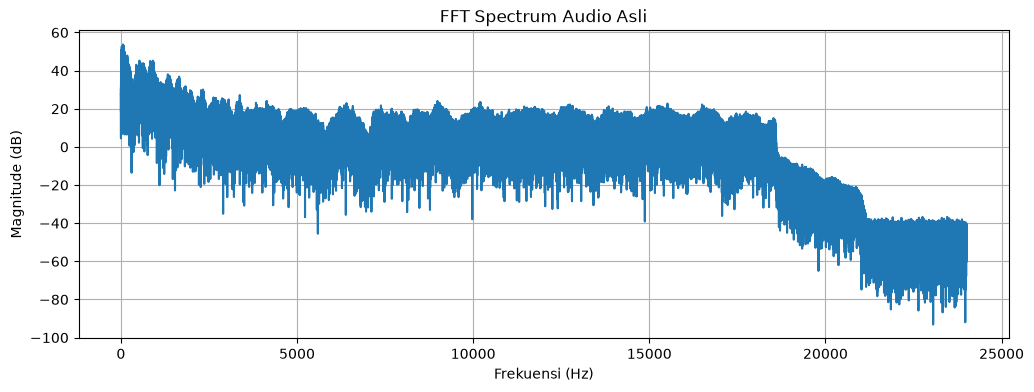

In [20]:
fft = np.fft.rfft(audio)

magnitudo_fft = np.abs(fft)

fft_db = 20 * np.log10(magnitudo_fft + 1e-10)

frekuensi = np.fft.rfftfreq(len(audio), 1 / sr)

plt.figure(figsize=(12, 4))
plt.plot(frekuensi, fft_db)

plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT Spectrum Audio Asli")
plt.grid()

plt.savefig("waveform_recording.png", dpi=300, bbox_inches="tight")

plt.show()

In [21]:
indeks_dominan = np.argmax(fft_db)

frekuensi_dominan = frekuensi[indeks_dominan]

nilai_dominan = fft_db[indeks_dominan]

print("Frekuensi dominan:", frekuensi_dominan, "Hz")
print("Magnitudo dominan:", nilai_dominan, "dB")

Frekuensi dominan: 58.87639146567718 Hz
Magnitudo dominan: 53.70278 dB


Dari grafik FFT, terlihat beberapa komponen frekuensi pada audio. Frekuensi yang paling dominan berada di sekitar 58,88 Hz dengan magnitudo sekitar 53,70 dB. Frekuensi ini dapat menjadi indikasi adanya suara atau noise berfrekuensi rendah yang cukup kuat pada rekaman.

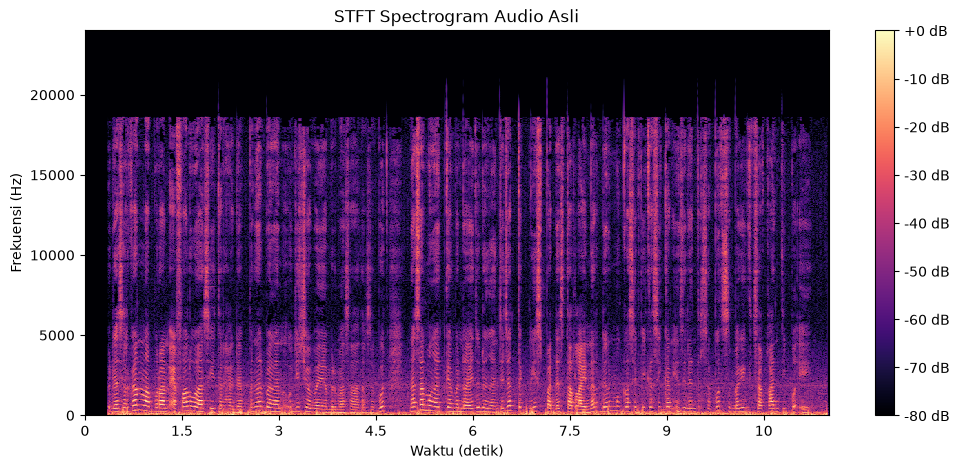

In [41]:
stft = librosa.stft(audio)

stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    stft_db,
    sr=sr,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.xlabel("Waktu (detik)")
plt.ylabel("Frekuensi (Hz)")
plt.title("STFT Spectrogram Audio Asli")

plt.savefig("stft_spectrogram.png", dpi=300, bbox_inches="tight")

plt.show()

Dari grafik STFT, kita bisa melihat perubahan frekuensi suara dari waktu ke waktu. Warna pada grafik menunjukkan kuat atau lemahnya energi pada frekuensi tertentu. Pada bagian suara, terlihat perubahan pola frekuensi karena adanya ucapan. Sementara itu, noise yang bersifat statis cenderung muncul pada frekuensi yang relatif tetap selama rekaman.    

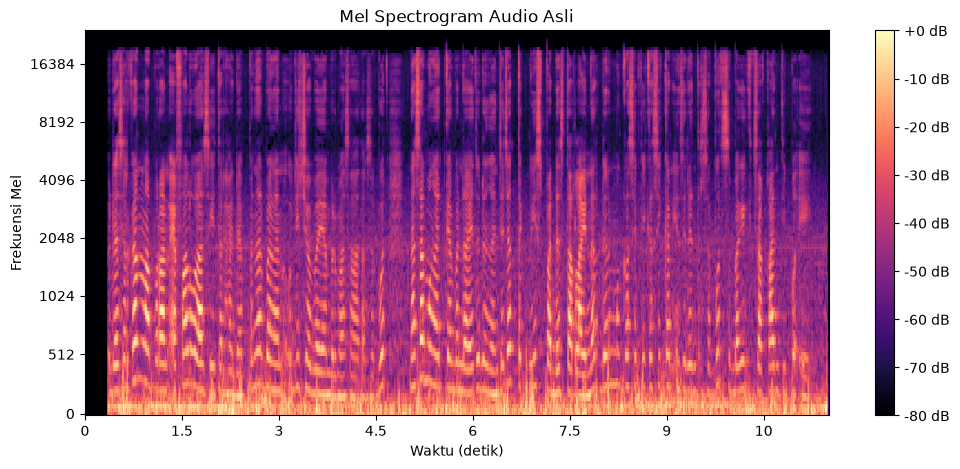

In [40]:
mel_spectrogram = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max
)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.xlabel("Waktu (detik)")
plt.ylabel("Frekuensi Mel")
plt.title("Mel Spectrogram Audio Asli")

plt.savefig("mel_spectrogram.png", dpi=300, bbox_inches="tight")

plt.show()

Dari grafik Mel Spectrogram, suara ditampilkan berdasarkan skala frekuensi Mel yang lebih sesuai dengan cara manusia mendengar. Pada bagian ketika berbicara, terlihat pola energi yang berubah-ubah karena adanya suara manusia. Mel Spectrogram membantu melihat karakteristik suara manusia dengan lebih jelas pada skala frekuensi yang digunakan.

In [27]:
import soundfile as sf

In [28]:
sr_baru = 8000

faktor = sr // sr_baru

audio_naive = audio[::faktor]

sf.write("audio_downsampled_naive.wav", audio_naive, sr_baru)

print("Sampling rate awal:", sr, "Hz")
print("Sampling rate baru:", sr_baru, "Hz")
print("Jumlah sampel setelah downsampling:", len(audio_naive))

Sampling rate awal: 48000 Hz
Sampling rate baru: 8000 Hz
Jumlah sampel setelah downsampling: 91990


In [30]:
import scipy.signal

In [31]:
audio_clean = scipy.signal.resample_poly(
    audio,
    sr_baru,
    sr
)

sf.write("audio_downsampled_clean.wav", audio_clean, sr_baru)

print("Sampling rate awal:", sr, "Hz")
print("Sampling rate baru:", sr_baru, "Hz")
print("Jumlah sampel setelah filtered resampling:", len(audio_clean))

Sampling rate awal: 48000 Hz
Sampling rate baru: 8000 Hz
Jumlah sampel setelah filtered resampling: 91990


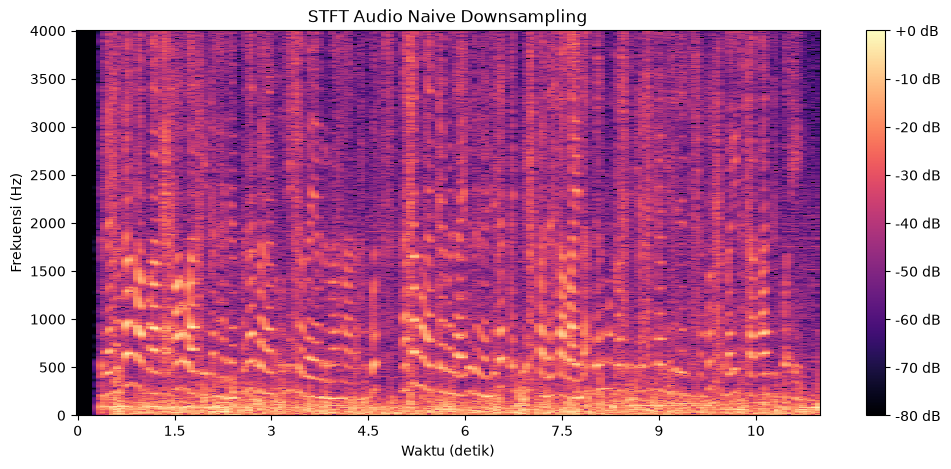

In [39]:
stft_naive = librosa.stft(audio_naive)

stft_naive_db = librosa.amplitude_to_db(
    np.abs(stft_naive),
    ref=np.max
)

stft_clean = librosa.stft(audio_clean)

stft_clean_db = librosa.amplitude_to_db(
    np.abs(stft_clean),
    ref=np.max
)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    stft_naive_db,
    sr=sr_baru,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.xlabel("Waktu (detik)")
plt.ylabel("Frekuensi (Hz)")
plt.title("STFT Audio Naive Downsampling")

plt.savefig("spectrogram_naive.png", dpi=300, bbox_inches="tight")

plt.show()

Pada naive downsampling, sampling rate audio diturunkan dari 48.000 Hz menjadi 8.000 Hz dengan mengambil setiap sampel ke-6 tanpa menggunakan filter anti-aliasing terlebih dahulu. Cara ini lebih sederhana, tetapi komponen frekuensi yang berada di atas batas Nyquist 4.000 Hz masih dapat ikut terbawa dan menyebabkan aliasing.

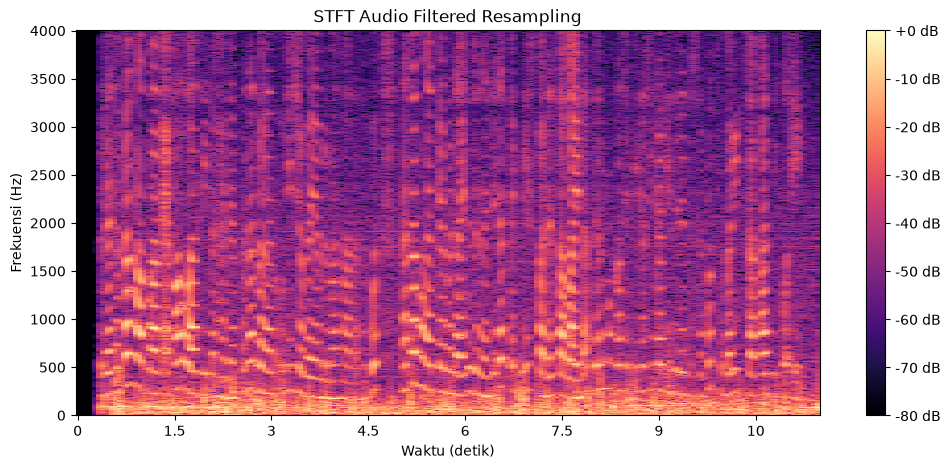

In [44]:
stft_clean = librosa.stft(audio_clean)

stft_clean_db = librosa.amplitude_to_db(
    np.abs(stft_clean),
    ref=np.max
)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    stft_clean_db,
    sr=sr_baru,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.xlabel("Waktu (detik)")
plt.ylabel("Frekuensi (Hz)")
plt.title("STFT Audio Filtered Resampling")

plt.savefig("spectrogram_clean.png", dpi=300, bbox_inches="tight")

plt.show()

Pada filtered resampling, sampling rate audio juga diturunkan dari 48.000 Hz menjadi 8.000 Hz. Bedanya, proses ini menggunakan filter anti-aliasing untuk mengurangi komponen frekuensi yang terlalu tinggi sebelum proses downsampling. Dengan begitu, risiko terjadinya aliasing dapat dikurangi dan hasil audio menjadi lebih bersih dibandingkan naive downsampling.

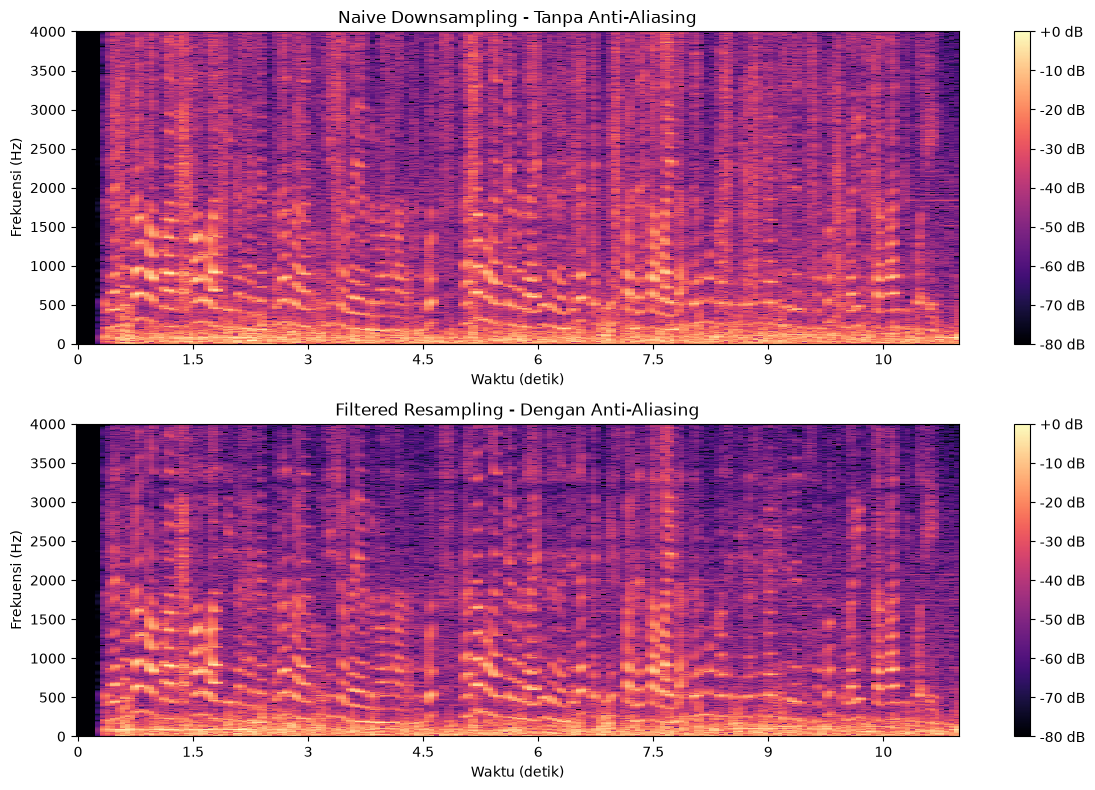

In [36]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
librosa.display.specshow(
    stft_naive_db,
    sr=sr_baru,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.xlabel("Waktu (detik)")
plt.ylabel("Frekuensi (Hz)")
plt.title("Naive Downsampling - Tanpa Anti-Aliasing")

plt.subplot(2, 1, 2)
librosa.display.specshow(
    stft_clean_db,
    sr=sr_baru,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.xlabel("Waktu (detik)")
plt.ylabel("Frekuensi (Hz)")
plt.title("Filtered Resampling - Dengan Anti-Aliasing")

plt.tight_layout()

plt.savefig("perbandingan_aliasing.png", dpi=300, bbox_inches="tight")

plt.savefig("spectrogram_naive.png", dpi=300, bbox_inches="tight")

plt.show()

Dari hasil perbandingan spectrogram, terlihat adanya perbedaan energi antara hasil naive dan clean. Pada naive downsampling, terlihat lebih banyak area berwarna merah dan oranye, sedangkan pada clean resampling lebih banyak area berwarna ungu. Perbedaan tersebut menunjukkan bahwa energi pada beberapa komponen frekuensi berbeda setelah proses resampling.

Perbedaan ini berkaitan dengan proses anti-aliasing. Naive downsampling tidak menggunakan filter sebelum sampling rate diturunkan, sedangkan clean resampling menggunakan filter anti-aliasing. Pada sampling rate 8.000 Hz, batas Nyquist adalah 4.000 Hz. Komponen frekuensi di atas batas tersebut perlu ditekan agar tidak menyebabkan aliasing.